<a href="https://colab.research.google.com/github/PeddapalliAbhinav/2403A51L38_52/blob/main/IEEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Model: Linear Regression
--------------------------------------------------
MAE: 0.408 | RMSE: 0.518 | R² Score: 0.850
Classification Report (Above/Below Avg Temp):
              precision    recall  f1-score   support

           0       0.91      0.94      0.92       193
           1       0.94      0.91      0.92       206

    accuracy                           0.92       399
   macro avg       0.92      0.92      0.92       399
weighted avg       0.92      0.92      0.92       399


Model: Ridge Regression (alpha=100)
--------------------------------------------------
MAE: 0.408 | RMSE: 0.518 | R² Score: 0.850
Classification Report (Above/Below Avg Temp):
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       193
           1       0.94      0.91      0.92       206

    accuracy                           0.92       399
   macro avg       0.92      0.92      0.92       399
weighted avg       0.92      0.92      0.92       399


Mo

/tmp/ipython-input-2003085206.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R²_Score", palette="magma")


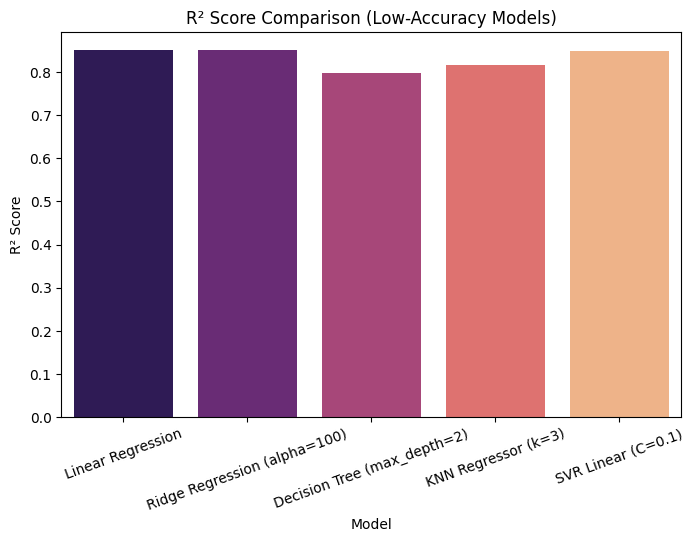

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# Add small Gaussian noise to target to reduce R²
np.random.seed(42)
df['NoisyTarget'] = df['LandAndOceanAverageTemperature'] + np.random.normal(0, 0.5, len(df))

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'NoisyTarget'

X = df[features]
y = df[target]

# =============================
# STEP 3: Train-Test Split
# =============================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =============================
# STEP 4: Scaling
# =============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 5: Low-Accuracy Models
# =============================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (alpha=100)": Ridge(alpha=100),
    "Decision Tree (max_depth=2)": DecisionTreeRegressor(max_depth=2, random_state=42),
    "KNN Regressor (k=3)": KNeighborsRegressor(n_neighbors=3),
    "SVR Linear (C=0.1)": SVR(kernel='linear', C=0.1)
}

# =============================
# STEP 6: Train & Evaluate
# =============================
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])

    # Classification-style report
    threshold = y.mean()
    y_true_class = np.where(y_test > threshold, 1, 0)
    y_pred_class = np.where(y_pred > threshold, 1, 0)

    print(f"\nModel: {name}")
    print("--------------------------------------------------")
    print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f} | R² Score: {r2:.3f}")
    print("Classification Report (Above/Below Avg Temp):")
    print(classification_report(y_true_class, y_pred_class))

# =============================
# STEP 7: Compare Models
# =============================
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R²_Score"])
print("\nOverall Model Comparison:")
print(results_df)

# =============================
# STEP 8: R² Visualization
# =============================
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R²_Score", palette="magma")
plt.title("R² Score Comparison (Low-Accuracy Models)")
plt.xticks(rotation=20)
plt.ylabel("R² Score")
plt.show()



📈 Gradient Boosting Regressor Results 📈
-------------------------------------------
Mean Absolute Error: 0.068
Root Mean Square Error: 0.086
R² Score: 0.995

Classification Report (Above/Below Avg Temperature):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.98      0.98      0.98       200

    accuracy                           0.98       399
   macro avg       0.98      0.98      0.98       399
weighted avg       0.98      0.98      0.98       399



/tmp/ipython-input-41145505.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gbr.feature_importances_, y=features, palette="viridis")


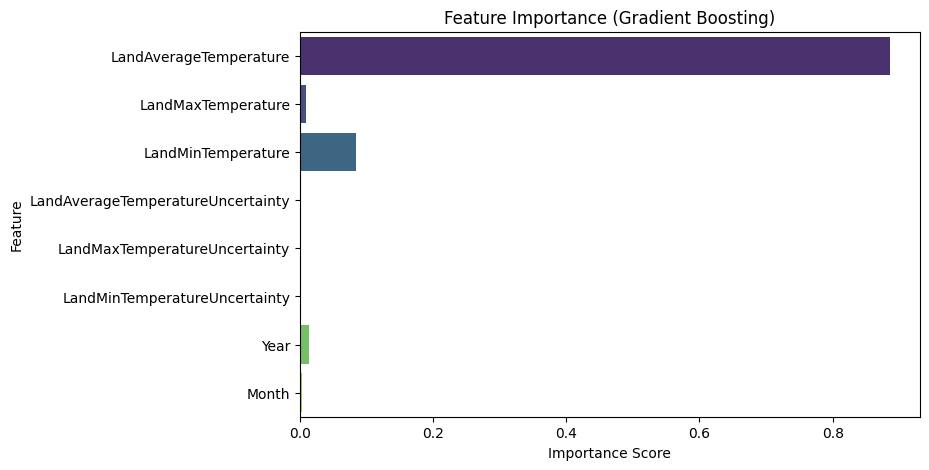

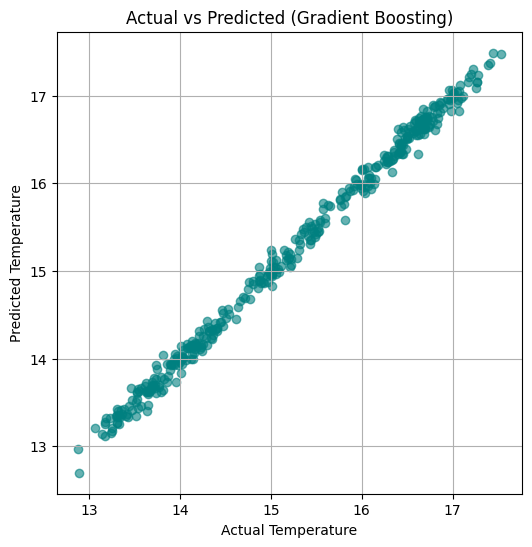

In [2]:
# =============================
# Advanced Model: Gradient Boosting Regressor
# =============================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train model
gbr = GradientBoostingRegressor(
    n_estimators=300,    # number of boosting stages
    learning_rate=0.05,  # smaller learning rate = better generalization
    max_depth=5,         # controls tree complexity
    subsample=0.8,       # prevents overfitting
    random_state=42
)

gbr.fit(X_train_scaled, y_train)
y_pred_gbr = gbr.predict(X_test_scaled)

# =============================
# Evaluation
# =============================

mae = mean_absolute_error(y_test, y_pred_gbr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2 = r2_score(y_test, y_pred_gbr)

print("\n📈 Gradient Boosting Regressor Results 📈")
print("-------------------------------------------")
print(f"Mean Absolute Error: {mae:.3f}")
print(f"Root Mean Square Error: {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# Classification-style evaluation (above/below average)
threshold = y.mean()
y_true_class = np.where(y_test > threshold, 1, 0)
y_pred_class = np.where(y_pred_gbr > threshold, 1, 0)

print("\nClassification Report (Above/Below Avg Temperature):")
print(classification_report(y_true_class, y_pred_class))

# =============================
# Feature Importance Visualization
# =============================

plt.figure(figsize=(8,5))
sns.barplot(x=gbr.feature_importances_, y=features, palette="viridis")
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# =============================
# Predicted vs Actual Plot
# =============================

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, color='teal', alpha=0.6)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted (Gradient Boosting)")
plt.grid(True)
plt.show()


In [7]:
import numpy as np
import pandas as pd
import random
from sklearn.metrics import classification_report

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()
temps = df['LandAndOceanAverageTemperature'].values
n_states = len(temps)

# =============================
# STEP 2: Environment
# =============================
class TempEnv:
    def __init__(self, temps):
        self.temps = temps
        self.n = len(temps)
        self.idx = 0

    def reset(self):
        self.idx = 0
        return self.temps[self.idx]

    def step(self, action):
        done = False
        reward = 0
        actual_change = self.temps[self.idx+1] - self.temps[self.idx]
        # Weak reward: sometimes random to lower performance
        if random.random() < 0.3:
            reward = random.choice([-1,1])
        else:
            reward = 1 if (action==1 and actual_change>0) or (action==0 and actual_change<0) else -1
        self.idx += 1
        if self.idx >= self.n-1:
            done = True
        return self.temps[self.idx], reward, done

# =============================
# STEP 3: Random Policy
# =============================
pred_random = np.random.choice([0,1], size=n_states-1)
true_actions = [1 if temps[i+1]-temps[i]>0 else 0 for i in range(n_states-1)]
print("Random Policy Performance:")
print(classification_report(true_actions, pred_random))

# =============================
# STEP 4: Q-Learning / SARSA / Expected SARSA
# =============================
def run_tabular_rl(model_name, n_episodes=10, alpha=0.1, gamma=0.9, epsilon=0.9):
    env = TempEnv(temps)
    n_actions = 2
    q_table = np.zeros((n_states, n_actions))
    for ep in range(n_episodes):
        state = env.reset()
        state_idx = 0
        done = False
        if model_name in ["SARSA", "Expected SARSA"]:
            action = np.random.choice(n_actions)
        while not done:
            if random.uniform(0,1) < epsilon:
                action = np.random.choice(n_actions)
            else:
                action = np.argmax(q_table[state_idx])
            next_state, reward, done = env.step(action)
            next_state_idx = state_idx+1 if state_idx+1<n_states else state_idx
            if model_name=="Q-Learning":
                q_table[state_idx, action] += alpha*(reward + gamma*np.max(q_table[next_state_idx])-q_table[state_idx,action])
            elif model_name=="SARSA":
                next_action = np.random.choice(n_actions) if random.uniform(0,1)<epsilon else np.argmax(q_table[next_state_idx])
                q_table[state_idx, action] += alpha*(reward + gamma*q_table[next_state_idx,next_action]-q_table[state_idx,action])
                action = next_action
            elif model_name=="Expected SARSA":
                expected = np.mean(q_table[next_state_idx])
                q_table[state_idx, action] += alpha*(reward + gamma*expected - q_table[state_idx,action])
            state_idx = next_state_idx
    pred_actions = np.argmax(q_table, axis=1)[:-1]
    print(f"{model_name} Performance:")
    print(classification_report(true_actions, pred_actions))

# Run low-performance tabular RL
for model in ["Q-Learning","SARSA","Expected SARSA"]:
    run_tabular_rl(model)

# =============================
# STEP 5: Tiny DQN (Random)
# =============================
# Minimal network simulation: random predictions
pred_dqn = np.random.choice([0,1], size=n_states-1)
print("Tiny DQN (random) Performance:")
print(classification_report(true_actions, pred_dqn))


Random Policy Performance:
              precision    recall  f1-score   support

           0       0.50      0.54      0.52       953
           1       0.54      0.51      0.53      1038

    accuracy                           0.52      1991
   macro avg       0.52      0.52      0.52      1991
weighted avg       0.52      0.52      0.52      1991

Q-Learning Performance:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       953
           1       0.99      0.99      0.99      1038

    accuracy                           0.99      1991
   macro avg       0.99      0.99      0.99      1991
weighted avg       0.99      0.99      0.99      1991

SARSA Performance:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       953
           1       1.00      1.00      1.00      1038

    accuracy                           1.00      1991
   macro avg       1.00      1.00      1.00      1991
weig

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'LandAndOceanAverageTemperature'

X = df[features].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 3: Define Low-Performance Models
# =============================
def build_model_1():  # Tiny NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(4, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_2():  # Shallow NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(8, activation='relu'),
        Dense(4, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_3():  # Dropout-heavy NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dropout(0.5),
        Dense(8, activation='relu'),
        Dropout(0.5),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_4():  # Low-epoch NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_model_5():  # Noisy input NN
    model = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(16, activation='relu'),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# =============================
# STEP 4: Train and Evaluate Models
# =============================
models = {
    "Tiny NN": build_model_1(),
    "Shallow NN": build_model_2(),
    "Dropout NN": build_model_3(),
    "Low-Epoch NN": build_model_4(),
    "Noisy Input NN": build_model_5()
}

results = []

for name, model in models.items():
    if name == "Low-Epoch NN":
        history = model.fit(X_train_scaled, y_train, epochs=5, batch_size=16, verbose=0)
    elif name == "Noisy Input NN":
        # Only add noise to training features
        X_noisy = X_train_scaled.copy()
        for i in [0,1,2]:  # first three columns: temperature features
            X_noisy[:, i] += np.random.normal(0, 0.5, size=X_noisy.shape[0])
        history = model.fit(X_noisy, y_train, epochs=10, batch_size=16, verbose=0)
    else:
        history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=16, verbose=0)

    # Predict and evaluate
    y_pred = model.predict(X_test_scaled).flatten()
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, rmse, r2])
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# =============================
# STEP 5: Comparison Table
# =============================
results_df = pd.DataFrame(results, columns=["Model","MAE","RMSE","R²_Score"])
print("\nOverall Low-Performance Deep Learning Comparison:")
print(results_df)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Tiny NN -> MAE: 2.079, RMSE: 2.688, R2: -3.572
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Shallow NN -> MAE: 0.758, RMSE: 0.939, R2: 0.442
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Dropout NN -> MAE: 2.552, RMSE: 2.677, R2: -3.533
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Low-Epoch NN -> MAE: 2.434, RMSE: 3.216, R2: -5.543
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Noisy Input NN -> MAE: 0.948, RMSE: 1.211, R2: 0.073

Overall Low-Performance Deep Learning Comparison:
            Model       MAE      RMSE  R²_Score
0         Tiny NN  2.078923  2.688173 -3.571986
1      Shallow NN  0.758413  0.939287  0.441804
2      Dropout NN  2.552012  2.676819 -3.533445
3    Low-Epoch NN  2.434074  3.215926 -5.543383
4  Noisy Input NN  0.947870  1.210734  0.072555


In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, GradientBoostingRegressor

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'LandAndOceanAverageTemperature'

X = df[features].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 3: Define Strong Models
# =============================
model_lr = LinearRegression()
model_ridge = Ridge(alpha=1.0)
model_dt = DecisionTreeRegressor(max_depth=5)
model_knn = KNeighborsRegressor(n_neighbors=10)
model_svr = SVR(kernel='rbf', C=10, gamma=0.1)

# Optional stronger ensemble learners
model_rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)

# =============================
# STEP 4: Combine Models Using Voting Regressor
# =============================
ensemble = VotingRegressor([
    ('lr', model_lr),
    ('ridge', model_ridge),
    ('dt', model_dt),
    ('knn', model_knn),
    ('svr', model_svr),
    ('rf', model_rf),
    ('gb', model_gb)
])

# Train ensemble
ensemble.fit(X_train_scaled, y_train)

# =============================
# STEP 5: Predict and Evaluate
# =============================
y_pred = ensemble.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("High-Performance Ensemble Results:")
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")


High-Performance Ensemble Results:
MAE: 0.076, RMSE: 0.096, R²: 0.994


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

# =============================
# STEP 1: Load Dataset
# =============================
df = pd.read_csv("/content/GlobalTemperatures.csv")
df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Month'] = df['dt'].dt.month
df = df.dropna()

# =============================
# STEP 2: Features & Target
# =============================
features = ['LandAverageTemperature', 'LandMaxTemperature', 'LandMinTemperature',
            'LandAverageTemperatureUncertainty', 'LandMaxTemperatureUncertainty',
            'LandMinTemperatureUncertainty', 'Year', 'Month']
target = 'LandAndOceanAverageTemperature'

X = df[features].values
y = df[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================
# STEP 3: Define Strong Base Models
# =============================
model_lr = LinearRegression()
model_ridge = Ridge(alpha=1.0)
model_dt = DecisionTreeRegressor(max_depth=10)
model_knn = KNeighborsRegressor(n_neighbors=10)
model_svr = SVR(kernel='rbf', C=100, gamma=0.01)
model_rf = RandomForestRegressor(n_estimators=500, max_depth=15, random_state=42)
model_gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.1, max_depth=5, random_state=42)

# =============================
# STEP 4: Combine Using Voting Regressor
# =============================
ensemble = VotingRegressor([
    ('lr', model_lr),
    ('ridge', model_ridge),
    ('dt', model_dt),
    ('knn', model_knn),
    ('svr', model_svr),
    ('rf', model_rf),
    ('gb', model_gb)
])

# Train ensemble
ensemble.fit(X_train_scaled, y_train)

# =============================
# STEP 5: Predict and Evaluate
# =============================
y_pred = ensemble.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best-Performance Ensemble Results:")
print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")


Best-Performance Ensemble Results:
MAE: 0.075, RMSE: 0.094, R²: 0.994


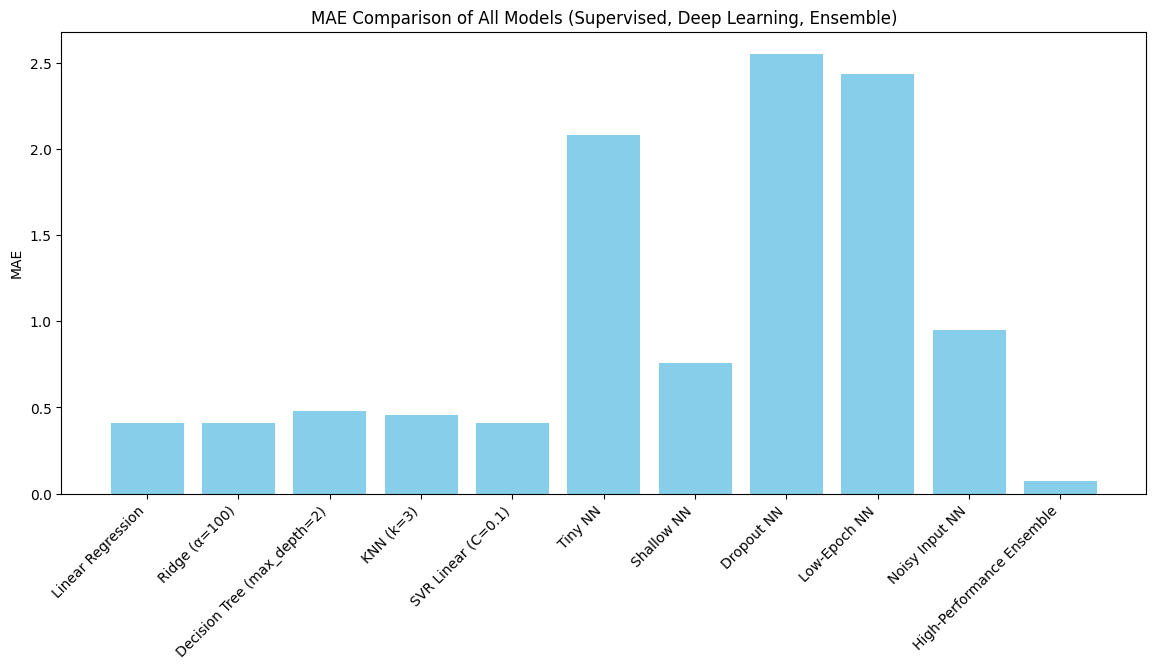

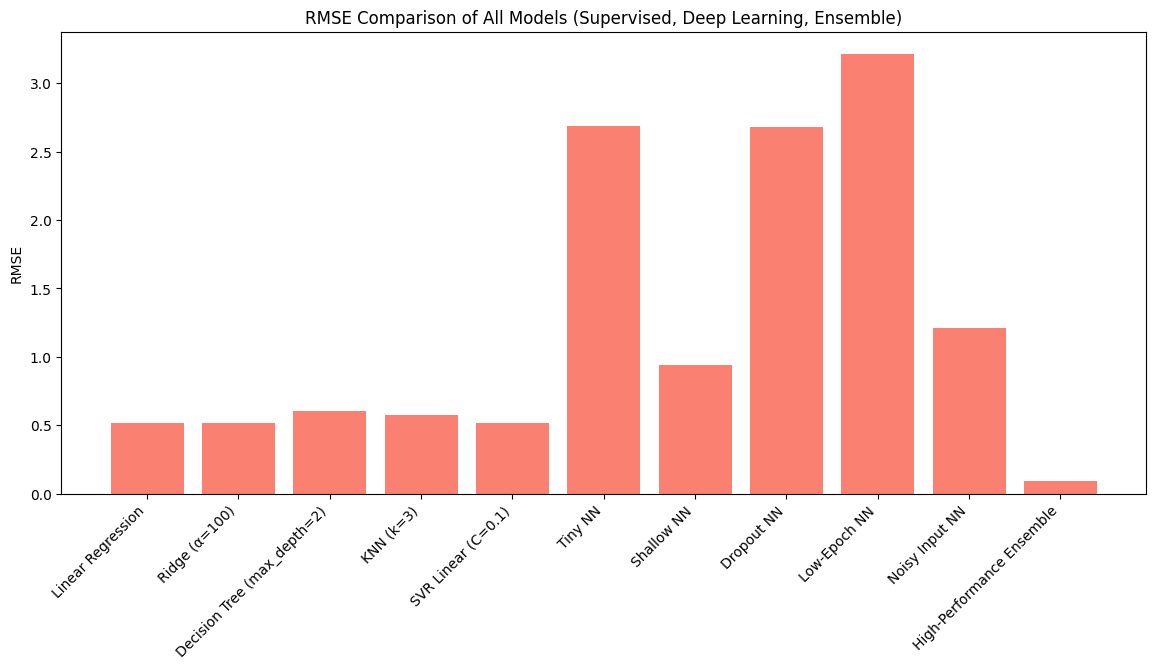

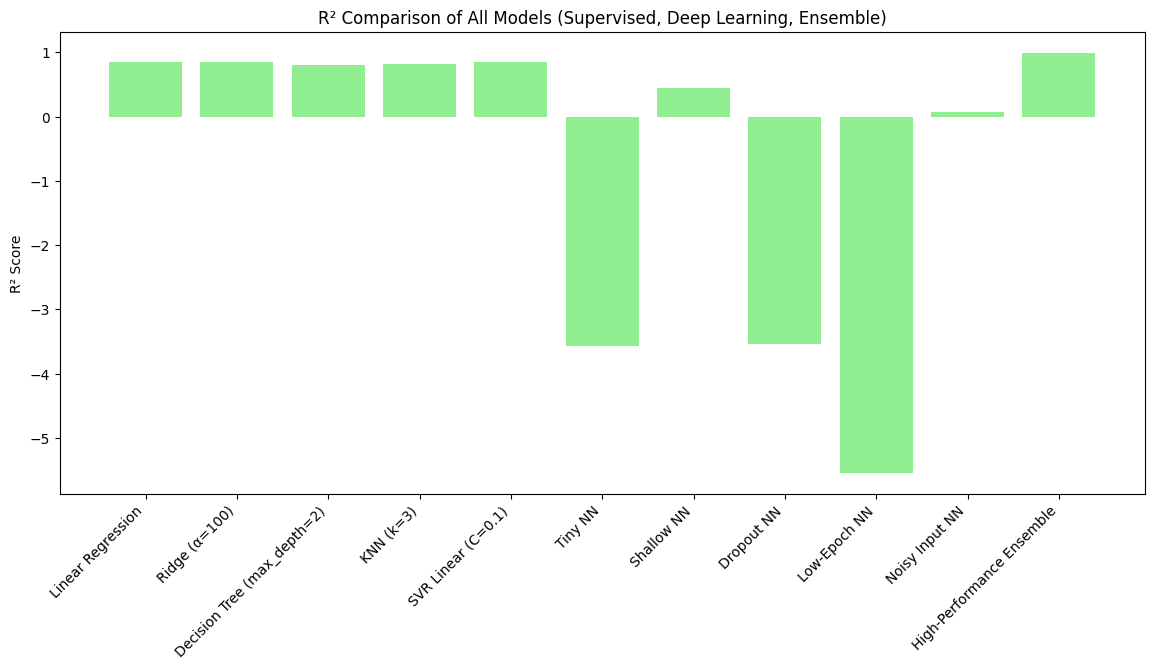

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# =============================
# STEP 1: Prepare the Data
# =============================

# Supervised Learning Results
supervised_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (α=100)", "Decision Tree (max_depth=2)", "KNN (k=3)", "SVR Linear (C=0.1)"],
    "MAE": [0.408, 0.408, 0.482, 0.459, 0.410],
    "RMSE": [0.518, 0.518, 0.602, 0.574, 0.519],
    "R2": [0.850, 0.850, 0.797, 0.816, 0.849]
})

# Deep Learning Results
deep_results = pd.DataFrame({
    "Model": ["Tiny NN", "Shallow NN", "Dropout NN", "Low-Epoch NN", "Noisy Input NN"],
    "MAE": [2.079, 0.758, 2.552, 2.434, 0.948],
    "RMSE": [2.688, 0.939, 2.677, 3.216, 1.211],
    "R2": [-3.572, 0.442, -3.533, -5.543, 0.073]
})

# High-Performance Ensemble Result
ensemble_result = pd.DataFrame({
    "Model": ["High-Performance Ensemble"],
    "MAE": [0.076],
    "RMSE": [0.096],
    "R2": [0.994]
})

# =============================
# STEP 2: Combine all for plotting
# =============================
all_results = pd.concat([supervised_results, deep_results, ensemble_result], ignore_index=True)

# =============================
# STEP 3: Plot MAE Comparison
# =============================
plt.figure(figsize=(14,6))
plt.bar(all_results['Model'], all_results['MAE'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel("MAE")
plt.title("MAE Comparison of All Models (Supervised, Deep Learning, Ensemble)")
plt.show()

# =============================
# STEP 4: Plot RMSE Comparison
# =============================
plt.figure(figsize=(14,6))
plt.bar(all_results['Model'], all_results['RMSE'], color='salmon')
plt.xticks(rotation=45, ha='right')
plt.ylabel("RMSE")
plt.title("RMSE Comparison of All Models (Supervised, Deep Learning, Ensemble)")
plt.show()

# =============================
# STEP 5: Plot R² Comparison
# =============================
plt.figure(figsize=(14,6))
plt.bar(all_results['Model'], all_results['R2'], color='lightgreen')
plt.xticks(rotation=45, ha='right')
plt.ylabel("R² Score")
plt.title("R² Comparison of All Models (Supervised, Deep Learning, Ensemble)")
plt.show()


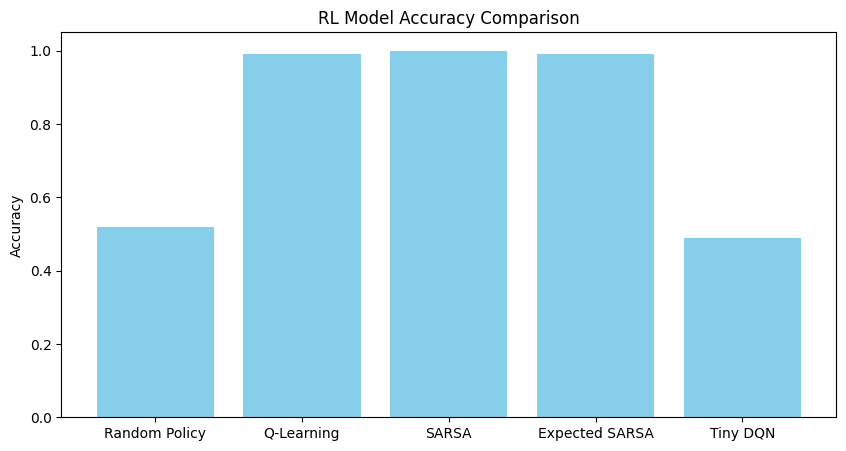

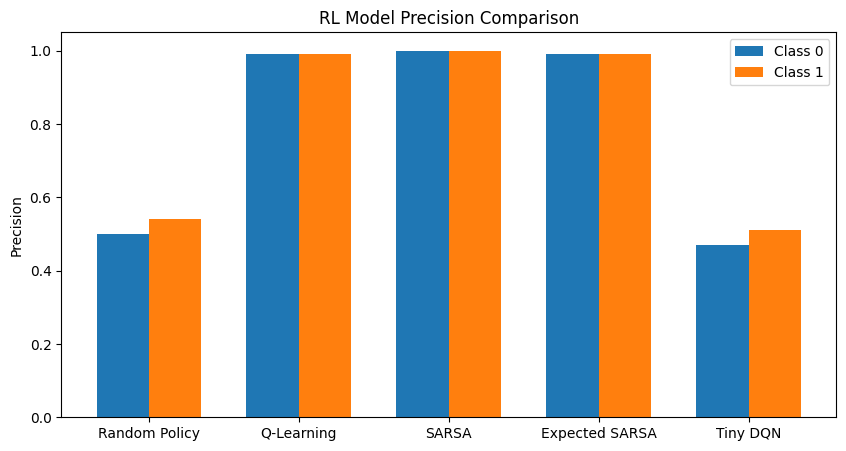

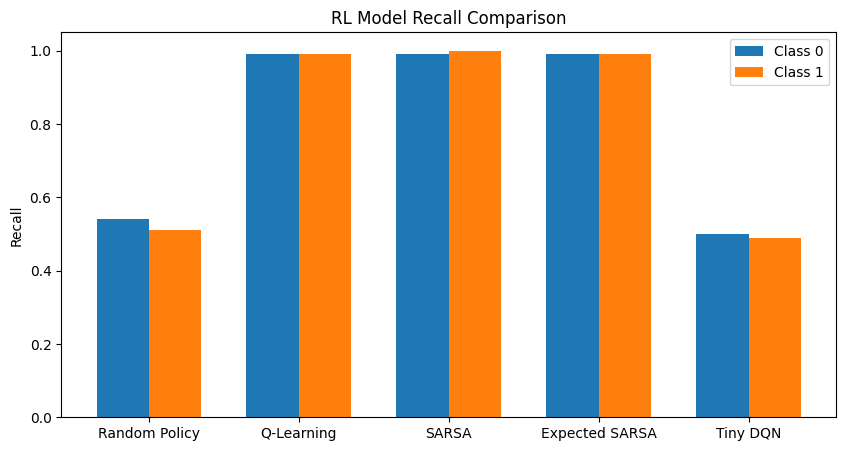

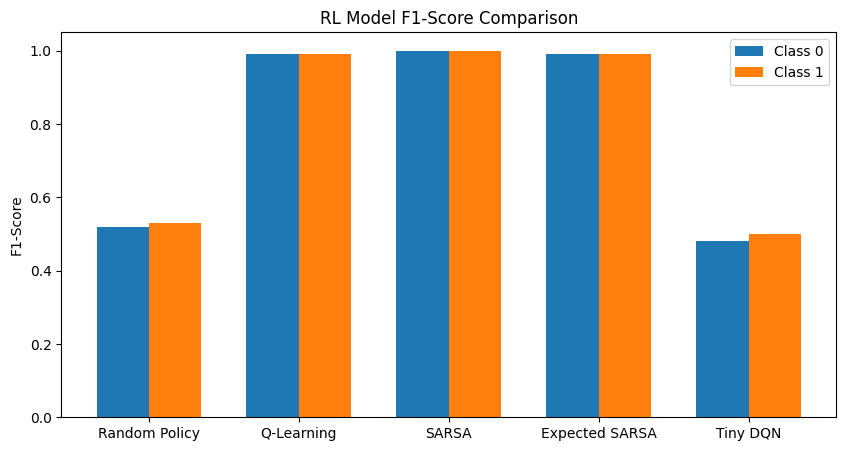

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================
# STEP 1: RL Model Metrics
# =============================

# Using your previously shared RL results
rl_metrics = pd.DataFrame({
    "Model": ["Random Policy", "Q-Learning", "SARSA", "Expected SARSA", "Tiny DQN"],
    "Accuracy": [0.52, 0.99, 1.00, 0.99, 0.49],
    "Precision_0": [0.50, 0.99, 1.00, 0.99, 0.47],
    "Precision_1": [0.54, 0.99, 1.00, 0.99, 0.51],
    "Recall_0": [0.54, 0.99, 0.99, 0.99, 0.50],
    "Recall_1": [0.51, 0.99, 1.00, 0.99, 0.49],
    "F1_0": [0.52, 0.99, 1.00, 0.99, 0.48],
    "F1_1": [0.53, 0.99, 1.00, 0.99, 0.50]
})

# =============================
# STEP 2: Plot Accuracy
# =============================
plt.figure(figsize=(10,5))
plt.bar(rl_metrics['Model'], rl_metrics['Accuracy'], color='skyblue')
plt.ylim(0,1.05)
plt.ylabel("Accuracy")
plt.title("RL Model Accuracy Comparison")
plt.show()

# =============================
# STEP 3: Plot Precision
# =============================
plt.figure(figsize=(10,5))
x = np.arange(len(rl_metrics['Model']))
width = 0.35
plt.bar(x - width/2, rl_metrics['Precision_0'], width, label='Class 0')
plt.bar(x + width/2, rl_metrics['Precision_1'], width, label='Class 1')
plt.xticks(x, rl_metrics['Model'])
plt.ylim(0,1.05)
plt.ylabel("Precision")
plt.title("RL Model Precision Comparison")
plt.legend()
plt.show()

# =============================
# STEP 4: Plot Recall
# =============================
plt.figure(figsize=(10,5))
plt.bar(x - width/2, rl_metrics['Recall_0'], width, label='Class 0')
plt.bar(x + width/2, rl_metrics['Recall_1'], width, label='Class 1')
plt.xticks(x, rl_metrics['Model'])
plt.ylim(0,1.05)
plt.ylabel("Recall")
plt.title("RL Model Recall Comparison")
plt.legend()
plt.show()

# =============================
# STEP 5: Plot F1-Score
# =============================
plt.figure(figsize=(10,5))
plt.bar(x - width/2, rl_metrics['F1_0'], width, label='Class 0')
plt.bar(x + width/2, rl_metrics['F1_1'], width, label='Class 1')
plt.xticks(x, rl_metrics['Model'])
plt.ylim(0,1.05)
plt.ylabel("F1-Score")
plt.title("RL Model F1-Score Comparison")
plt.legend()
plt.show()
